In [9]:
import matplotlib.pyplot as plt

from imagematerials.rest_of.metals_projections import (
    steel_projection, 
    aluminium_projection, 
    copper_projection)

from imagematerials.rest_of.preprocessing.regressions_all_materials import *

from imagematerials.rest_of.water import water_consumption

from imagematerials.rest_of.biomass import biomass_data

from imagematerials.rest_of.fossil_fuels import fossil_fuel_data

from imagematerials.rest_of.nmm_projections import (cement_projection, 
                                                    sand_projections, 
                                                    limestone_projection,
                                                    clay_projections) 

from pathlib import Path


In [10]:
results = fit_models_all_materials()
make_gompertz_coefs_da(results)
historic_other_fraction_comsumption_to_xr(results)

SSP2_M_CP
low_steady assigned to class_ 4
low_steady assigned to class_ 5
low_steady assigned to class_ 6
low_steady assigned to class_ 7
low_steady assigned to class_ 8
low_steady assigned to class_ 9
low_steady assigned to class_ 14
low_steady assigned to class_ 17
low_steady assigned to class_ 18
low_steady assigned to class_ 21
low_steady assigned to class_ 22
low_steady assigned to class_ 24
low_steady assigned to class_ 25
low_steady assigned to class_ 26
low assigned to class_ 6
low assigned to class_ 8
low assigned to class_ 10
low assigned to class_ 26
all_regions assigned to class_ 24
all_regions assigned to class_ 23


In [11]:
# Run IMAGE Materials projections
scenario_list = {"SSP2_M_CP":("SSP2_M_CP",["base"]),
                 "SSP2_VLLO":("SSP2_VLLO",["base"]),
                 "SSP2_VLLO_LifeTech":("SSP2_VLLO_LifeTech",["base"])}

scenario_base_path = Path("../../../data/raw") / 'RO_scenarios'

In [12]:
results = {}

for scenario in scenario_list.keys():
    print(scenario)
    # Run all projections for this scenario
    copper = copper_projection(scenario=scenario)
    steel = steel_projection(scenario=scenario)
    aluminium = aluminium_projection(scenario=scenario)
    cement = cement_projection(scenario=scenario)
    sand = sand_projections(scenario=scenario)
    limestone = limestone_projection(scenario=scenario)
    clay = clay_projections(scenario=scenario)
    #biomass = biomass_data(scenario=scenario)
    fossil_fuel = fossil_fuel_data(scenario=scenario)
    water = water_consumption(scenario=scenario)
    
    # Store model objects or just their outputs
    results[scenario] = {
        'copper': copper,
        'steel': steel,
        'aluminium': aluminium,
        'cement': cement,
        'sand': sand,
        'limestone': limestone,
        'clay': clay,
        #'biomass': biomass,
        'fossil_fuel': fossil_fuel,
        'water': water
    }

SSP2_M_CP
low_steady assigned to class_ 4
low_steady assigned to class_ 5
low_steady assigned to class_ 6
low_steady assigned to class_ 7
low_steady assigned to class_ 8
low_steady assigned to class_ 9
low_steady assigned to class_ 14
low_steady assigned to class_ 17
low_steady assigned to class_ 18
low_steady assigned to class_ 21
low_steady assigned to class_ 22
low_steady assigned to class_ 24
low_steady assigned to class_ 25
low_steady assigned to class_ 26
low assigned to class_ 6
low assigned to class_ 8
low assigned to class_ 10
low assigned to class_ 26
all_regions assigned to class_ 24
all_regions assigned to class_ 23
SSP2_VLLO


FileNotFoundError: [Errno 2] No such file or directory: '..\\..\\..\\data\\raw\\image\\SSP2_VLLO\\Socioeconomic\\gdp_pc.scn'

KeyError: 'SSP2_M_CP'

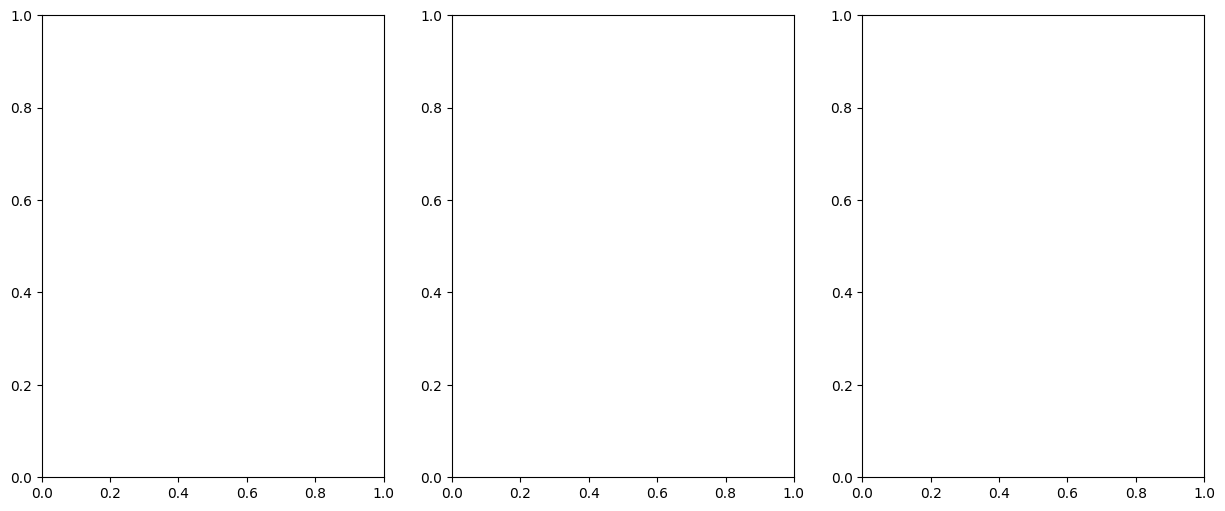

In [ ]:
# Plot metal base scenario (SSP2_M_CP) with historic data

tonne_to_megatonne = 1e6

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 6), sharey=False)
ax1, ax2, ax3 = axes
ax1.plot(results['SSP2_M_CP']['steel'].projection_per_region_total.sum(axis=1).loc[2012:]/tonne_to_megatonne + results['SSP2_M_CP']['steel'].image_mat_data.sum(axis=1).loc[2012:]/tonne_to_megatonne, 
        label='SSP2_M_CP - total demand', color='blue', linestyle='--') 
ax1.plot(results['SSP2_M_CP']['steel'].image_mat_data.sum(axis=1).loc[1960:]/tonne_to_megatonne, label='SSP2_M_CP Image Mat', linestyle='--', color='red')
ax1.plot(results['SSP2_M_CP']['steel'].historic_consumption_data.sum(axis=1).loc[:]/tonne_to_megatonne, label='SSP2_M_CP Historic Consumption', color='black')
ax1.plot((results['SSP2_M_CP']['steel'].projection_per_region_adapted_alpha.loc[2050:, ].sum(axis=1)/tonne_to_megatonne + 
          results['SSP2_M_CP']['steel'].image_mat_data.sum(axis=1).loc[2050:]/tonne_to_megatonne)
         , linestyle='--', label ='SSP2_VLLO_LifeTech', color='green')

# x axis title
ax1.set_xlabel('Year')
# y axis title
ax1.set_ylabel('Steel Consumption (Mt)')
ax1.legend()


ax2.plot(results['SSP2_M_CP']['aluminium'].projection_per_region_total.sum(axis=1).loc[2014:]/tonne_to_megatonne + results['SSP2_M_CP']['aluminium'].image_mat_data.sum(axis=1).loc[2014:]/tonne_to_megatonne, 
        label='SSP2_M_CP - total demand', color='blue', linestyle='--') 
ax2.plot(results['SSP2_M_CP']['aluminium'].image_mat_data.sum(axis=1).loc[1960:]/tonne_to_megatonne, label='SSP2_M_CP Image Mat', linestyle='--', color='red')
ax2.plot(results['SSP2_M_CP']['aluminium'].historic_consumption_data.sum(axis=1).loc[:2014]/tonne_to_megatonne, label='SSP2_M_CP Historic Consumption', color='black')
ax2.plot((results['SSP2_M_CP']['aluminium'].projection_per_region_adapted_alpha.loc[2050:, ].sum(axis=1)/tonne_to_megatonne + 
          results['SSP2_M_CP']['aluminium'].image_mat_data.sum(axis=1).loc[2050:]/tonne_to_megatonne)
         , linestyle='--', label ='SSP2_VLLO_LifeTech', color='green')

ax2.set_xlabel('Year')
ax2.set_ylabel('Aluminum Consumption (Mt)')
ax2.legend()


ax3.plot(results['SSP2_M_CP']['copper'].projection_per_region_total.sum(axis=1).loc[2017:]/tonne_to_megatonne + results['SSP2_M_CP']['copper'].image_mat_data.sum(axis=1).loc[2017:]/tonne_to_megatonne, 
        label='SSP2_M_CP - total demand', color='blue', linestyle='--') 
ax3.plot(results['SSP2_M_CP']['copper'].image_mat_data.sum(axis=1).loc[2000:]/tonne_to_megatonne, label='SSP2_M_CP Image Mat', linestyle='--', color='red')
ax3.plot(results['SSP2_M_CP']['copper'].historic_consumption_data.sum(axis=1).loc[:]/tonne_to_megatonne, label='SSP2_M_CP Historic Consumption', color='black')
ax3.plot((results['SSP2_M_CP']['copper'].projection_per_region_adapted_alpha.loc[2050:, ].sum(axis=1)/tonne_to_megatonne + 
          results['SSP2_M_CP']['copper'].image_mat_data.sum(axis=1).loc[2050:]/tonne_to_megatonne)
         , linestyle='--', label ='SSP2_VLLO_LifeTech', color='green')


ax3.set_xlabel('Year')
ax3.set_ylabel('Copper Consumption (Mt)')
ax3.legend()



In [ ]:
results['SSP2_M_CP']['aluminium'].historic_consumption_data.sum(axis=1).loc[:2014]/tonne_to_megatonne

In [ ]:
results['SSP2_M_CP'].get('steel').region_model_match

In [ ]:
# Plot nmm base scenario (SSP2_M_CP) with historic data

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10), sharey=False)
ax1, ax2, = axes[0]
ax3, ax4 = axes[1]

ax1.plot(results['SSP2_M_CP']['cement'].projection_per_region_total.sum(axis=1).loc[2016:]/tonne_to_megatonne + results['SSP2_M_CP']['cement'].image_mat_data.sum(axis=1).loc[2016:]/tonne_to_megatonne, 
        label='SSP2_M_CP - total demand', color='blue', linestyle='--') 
ax1.plot(results['SSP2_M_CP']['cement'].image_mat_data.sum(axis=1).loc[1960:]/tonne_to_megatonne, label='SSP2_M_CP Image Mat', linestyle='--', color='red')
ax1.plot(results['SSP2_M_CP']['cement'].historic_consumption_data.sum(axis=1).loc[:]/tonne_to_megatonne, label='SSP2_M_CP Historic Consumption', color='black')
ax1.plot((results['SSP2_M_CP']['cement'].projection_per_region_adapted_alpha.loc[2050:, ].sum(axis=1)/tonne_to_megatonne + 
          results['SSP2_M_CP']['cement'].image_mat_data.sum(axis=1).loc[2050:]/tonne_to_megatonne)
         , linestyle='--', label ='SSP2_VLLO_LifeTech', color='green')


# x axis title
ax1.set_xlabel('Year')
# y axis title
ax1.set_ylabel('cement Consumption (Mt)')
ax1.legend()


ax2.plot(results['SSP2_M_CP']['sand'].projection_per_region_total.sum(axis=1).loc[2017:]/tonne_to_megatonne + results['SSP2_M_CP']['sand'].image_mat_data.sum(axis=1).loc[2017:]/tonne_to_megatonne, 
        label='SSP2_M_CP - total demand', color='blue', linestyle='--') 
ax2.plot(results['SSP2_M_CP']['sand'].image_mat_data.sum(axis=1).loc[1960:]/tonne_to_megatonne, label='SSP2_M_CP Image Mat', linestyle='--', color='red')
ax2.plot(results['SSP2_M_CP']['sand'].historic_consumption_data.sum(axis=1).loc[:2014]/tonne_to_megatonne, label='SSP2_M_CP Historic Consumption', color='black')
ax2.plot((results['SSP2_M_CP']['sand'].projection_per_region_adapted_alpha.loc[2050:, ].sum(axis=1)/tonne_to_megatonne + 
          results['SSP2_M_CP']['sand'].image_mat_data.sum(axis=1).loc[2050:]/tonne_to_megatonne)
         , linestyle='--', label ='SSP2_VLLO_LifeTech', color='green')


ax2.set_xlabel('Year')
ax2.set_ylabel('Sand Consumption (Mt)')
ax2.legend()


ax3.plot(results['SSP2_M_CP']['limestone'].projection_per_region_total.sum(axis=1).loc[2017:]/tonne_to_megatonne, 
        label='SSP2_M_CP - total demand', color='blue', linestyle='--') 
ax3.plot(results['SSP2_M_CP']['limestone'].historic_consumption_data.sum(axis=1).loc[:]/tonne_to_megatonne, label='SSP2_M_CP Historic Consumption', color='black')
ax3.plot((results['SSP2_M_CP']['limestone'].projection_per_region_adapted_alpha.loc[2050:, ].sum(axis=1)/tonne_to_megatonne)
         , linestyle='--', label ='SSP2_VLLO_LifeTech', color='green')



ax3.set_xlabel('Year')
ax3.set_ylabel('limestone Consumption (Mt)')
ax3.legend()


ax4.plot(results['SSP2_M_CP']['clay'].projection_per_region_total.sum(axis=1).loc[2017:]/tonne_to_megatonne, 
        label='SSP2_M_CP - total demand', color='blue', linestyle='--') 
ax4.plot(results['SSP2_M_CP']['clay'].historic_consumption_data.sum(axis=1).loc[:]/tonne_to_megatonne, label='SSP2_M_CP Historic Consumption', color='black')
ax4.plot((results['SSP2_M_CP']['clay'].projection_per_region_adapted_alpha.loc[2050:, ].sum(axis=1)/tonne_to_megatonne)
         , linestyle='--', label ='SSP2_VLLO_LifeTech', color='green')

ax4.set_xlabel('Year')
ax4.set_ylabel('clay Consumption (Mt)')
ax4.legend()


In [ ]:
# Plot metal base scenario (SSP2_M_CP) with historic data

tonne_to_megatonne = 1e6

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 6), sharey=False)
ax1, ax2, ax3 = axes
ax1.plot(results['SSP2_M_CP']['steel'].projection_per_region_total.sum(axis=1).loc[2012:]/tonne_to_megatonne, 
         label='SSP2_M_CP - total demand', color='blue', linestyle='--') 

ax1.plot(results['SSP2_M_CP']['steel'].image_mat_data.sum(axis=1).loc[1960:]/tonne_to_megatonne, label='SSP2_M_CP Image Mat', linestyle='--', color='red')

ax1.plot(results['SSP2_M_CP']['steel'].historic_other_fraction_consumption.sum(axis=1).loc[:]/tonne_to_megatonne, label='SSP2_M_CP Historic Consumption', color='black')

ax1.plot(results['SSP2_M_CP']['steel'].projection_per_region_adapted_alpha.loc[2050:, ].sum(axis=1)/tonne_to_megatonne,
          linestyle='--', label ='SSP2_VLLO_LifeTech', color='green')


ax1.set_xlabel('Year')
ax1.set_ylabel('Steel Consumption (Mt)')
ax1.legend()


ax2.plot(results['SSP2_M_CP']['aluminium'].projection_per_region_total.sum(axis=1).loc[2014:]/tonne_to_megatonne + results['SSP2_M_CP']['aluminium'].image_mat_data.sum(axis=1).loc[2014:]/tonne_to_megatonne, 
        label='SSP2_M_CP - total demand', color='blue', linestyle='--') 
ax2.plot(results['SSP2_M_CP']['aluminium'].image_mat_data.sum(axis=1).loc[1960:]/tonne_to_megatonne, label='SSP2_M_CP Image Mat', linestyle='--', color='red')
ax2.plot(results['SSP2_M_CP']['aluminium'].historic_consumption_data.sum(axis=1).loc[:2014]/tonne_to_megatonne, label='SSP2_M_CP Historic Consumption', color='black')
ax2.plot((results['SSP2_M_CP']['aluminium'].projection_per_region_adapted_alpha.loc[2050:, ].sum(axis=1)/tonne_to_megatonne + 
          results['SSP2_M_CP']['aluminium'].image_mat_data.sum(axis=1).loc[2050:]/tonne_to_megatonne)
         , linestyle='--', label ='SSP2_VLLO_LifeTech', color='green')

ax2.set_xlabel('Year')
ax2.set_ylabel('Aluminum Consumption (Mt)')
ax2.legend()


ax3.plot(results['SSP2_M_CP']['copper'].projection_per_region_total.sum(axis=1).loc[2017:]/tonne_to_megatonne + results['SSP2_M_CP']['copper'].image_mat_data.sum(axis=1).loc[2017:]/tonne_to_megatonne, 
        label='SSP2_M_CP - total demand', color='blue', linestyle='--') 
ax3.plot(results['SSP2_M_CP']['copper'].image_mat_data.sum(axis=1).loc[2000:]/tonne_to_megatonne, label='SSP2_M_CP Image Mat', linestyle='--', color='red')
ax3.plot(results['SSP2_M_CP']['copper'].historic_consumption_data.sum(axis=1).loc[:]/tonne_to_megatonne, label='SSP2_M_CP Historic Consumption', color='black')
ax3.plot((results['SSP2_M_CP']['copper'].projection_per_region_adapted_alpha.loc[2050:, ].sum(axis=1)/tonne_to_megatonne + 
          results['SSP2_M_CP']['copper'].image_mat_data.sum(axis=1).loc[2050:]/tonne_to_megatonne)
         , linestyle='--', label ='SSP2_VLLO_LifeTech', color='green')


ax3.set_xlabel('Year')
ax3.set_ylabel('Copper Consumption (Mt)')
ax3.legend()



In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(results['SSP2_M_CP']['copper'].projection_per_region_adapted_alpha.loc[2050:, ].sum(axis=1)/tonne_to_megatonne, linestyle='--')
ax.plot(results['SSP2_M_CP']['copper'].projection_per_region_total.sum(axis=1)/tonne_to_megatonne, label='SSP2_M_CP - total demand', color='blue')


In [ ]:
results['SSP2_M_CP']['copper'].projection_per_region_adapted_alpha

In [ ]:
# Plot metal base scenario (SSP2_M_CP) with historic data

tonne_to_megatonne = 1e6

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 6), sharey=False)
ax1, ax2, ax3 = axes
ax1.plot(results['SSP2_M_CP']['steel'].projection_per_region_total.sum(axis=1).loc[2012:]/tonne_to_megatonne + results['SSP2_M_CP']['steel'].image_mat_data.sum(axis=1).loc[2012:]/tonne_to_megatonne, 
        label='SSP2_M_CP - total demand', color='blue', linestyle='--') 
ax1.plot(results['SSP2_M_CP']['steel'].projection_per_region_adapted_alpha.sum(axis=1).loc[2050:]/tonne_to_megatonne + results['SSP2_M_CP']['steel'].image_mat_data.sum(axis=1).loc[2050:]/tonne_to_megatonne
         , label='SSP2_M_CP Adapted Alpha', linestyle='--', color='green')
ax1.plot(results['SSP2_M_CP']['steel'].image_mat_data.sum(axis=1).loc[1960:]/tonne_to_megatonne, label='SSP2_M_CP Image Mat', linestyle='--', color='red')
ax1.plot(results['SSP2_M_CP']['steel'].historic_consumption_data.sum(axis=1).loc[:]/tonne_to_megatonne, label='SSP2_M_CP Historic Consumption', color='black')

# x axis title
ax1.set_xlabel('Year')
# y axis title
ax1.set_ylabel('Steel Consumption (Mt)')
ax1.legend()


ax2.plot(results['SSP2_M_CP']['aluminium'].projection_per_region_total.sum(axis=1).loc[2014:]/tonne_to_megatonne + results['SSP2_M_CP']['aluminium'].image_mat_data.sum(axis=1).loc[2014:]/tonne_to_megatonne, 
        label='SSP2_M_CP - total demand', color='blue', linestyle='--') 
ax2.plot(results['SSP2_M_CP']['aluminium'].image_mat_data.sum(axis=1).loc[1960:]/tonne_to_megatonne, label='SSP2_M_CP Image Mat', linestyle='--', color='red')
ax2.plot(results['SSP2_M_CP']['aluminium'].historic_consumption_data.sum(axis=1).loc[:2014]/tonne_to_megatonne, label='SSP2_M_CP Historic Consumption', color='black')

ax2.set_xlabel('Year')
ax2.set_ylabel('Aluminum Consumption (Mt)')
ax2.legend()


ax3.plot(results['SSP2_M_CP']['copper'].projection_per_region_total.sum(axis=1).loc[2017:]/tonne_to_megatonne + results['SSP2_M_CP']['copper'].image_mat_data.sum(axis=1).loc[2017:]/tonne_to_megatonne, 
        label='SSP2_M_CP - total demand', color='blue', linestyle='--') 
ax3.plot(results['SSP2_M_CP']['copper'].image_mat_data.sum(axis=1).loc[2000:]/tonne_to_megatonne, label='SSP2_M_CP Image Mat', linestyle='--', color='red')
ax3.plot(results['SSP2_M_CP']['copper'].historic_consumption_data.sum(axis=1).loc[:]/tonne_to_megatonne, label='SSP2_M_CP Historic Consumption', color='black')

ax3.set_xlabel('Year')
ax3.set_ylabel('Copper Consumption (Mt)')
ax3.legend()



In [ ]:
results['SSP2_M_CP']['fossil_fuel']['fossils_primary'] - results['SSP2_VLLO_LifeTech']['fossil_fuel']['fossils_primary']

In [ ]:
year = 2050
scenario = 'SSP2_M_CP'
# convert fom petatonnes

fossil_fuels = results[scenario]['fossil_fuel']['fossils_primary_converted'].sum(axis = 1).loc[2050].sum() / 1e12  # Convert to megatonnes
fossil_fuels

In [ ]:
import numpy as np
kg_to_billion_tonnes = 1e9

# Create a figure with 3 scenarios as columsn and 4 materials as rows
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 12), sharey=False)
ax1, ax2, ax3 = axes[0]
ax4, ax5, ax6 = axes[1]
ax7, ax8, ax9 = axes[2]
ax10, ax11, ax12 = axes[3]
ax13, ax14, ax15 = axes[4]


# Scenario titles
for ax, scenario in zip([ax1, ax2, ax3], scenario_list):
    ax.set_title(scenario)

# Water consumption
for ax, scenario in zip(axes[0], scenario_list):
    ax.set_title(scenario)
    years = results[scenario]['water'][0].loc[2020:].index
    electricity = results[scenario]['water'][0].sum(axis=1).loc[2020:]
    industrial  = results[scenario]['water'][1].sum(axis=1).loc[2020:]
    municipality= results[scenario]['water'][2].sum(axis=1).loc[2020:]
    ax.stackplot(
        years,
        electricity,
        industrial,
        municipality,
        labels=['electricity', 'industrial', 'municipality'],
        colors=['orange', 'lightblue', 'gray']
    )
    ax.set_xlabel('Year')
    ax.set_ylabel('Water Consumption')
    ax.legend()

# Fossil fuel consumption
for ax, scenario in zip(axes[1], scenario_list):
    # define years as a numpy list from 2020 to 2100
    years = list(range(2020, 2101))
    coal = results[scenario]['fossil_fuel'].get('fossils_final_converteted').get('coal').query("DIM_2 == 10").sum(axis=1).loc[2020:]/kg_to_billion_tonnes
    heavy_oil = results[scenario]['fossil_fuel'].get('fossils_final_converteted').get('heavy oil').query("DIM_2 == 10").sum(axis=1).loc[2020:]/kg_to_billion_tonnes
    light_oil = results[scenario]['fossil_fuel'].get('fossils_final_converteted').get('light oil').query("DIM_2 == 10").sum(axis=1).loc[2020:]/kg_to_billion_tonnes
    natural_gas = results[scenario]['fossil_fuel'].get('fossils_final_converteted').get('natural gas').query("DIM_2 == 10").sum(axis=1).loc[2020:]/kg_to_billion_tonnes
    ax.stackplot(
        years,
        coal,
        heavy_oil,
        light_oil,
        natural_gas,
        labels=['coal', 'heavy oil', 'light oil', 'natural gas'],
        colors=['black', 'brown', 'orange', 'blue']
    )
    ax.set_ylabel('Fossil Fuel Consumption [bt]')
    ax.legend()

# Biomass consumption
for ax, scenario in zip(axes[2], scenario_list):

    crop_dict = results[scenario]['biomass'].get('consumption_in_categories')
    years = crop_dict[next(iter(crop_dict))].loc[2020:].index
    crop_names = list(crop_dict.keys())
    if 'total' in crop_names:
        crop_names.remove('total')
    crop_values = [crop_dict[name].loc[2020:, :26].sum(axis=1).values for name in crop_names]

    ax.stackplot(years, *crop_values, labels=crop_names)
    ax.set_xlabel('Year')
    ax.set_ylabel('Biomass Consumption [bt]')
    ax.set_ylim(0, 16)  
    ax.legend(loc='upper left')
    plt.tight_layout()

# Metals consumption
for ax, scenario in zip(axes[3], scenario_list):
    if scenario == 'SSP2_M_CP':
        steel = results[scenario]['steel'].projection_per_region_total.sum(axis=1).loc[2020:2060].values / tonne_to_megatonne + results[scenario]['steel'].image_mat_data.sum(axis=1).loc[2020:2060]/tonne_to_megatonne
        aluminium = results[scenario]['aluminium'].projection_per_region_total.sum(axis=1).loc[2020:2060].values / tonne_to_megatonne + results[scenario]['aluminium'].image_mat_data.sum(axis=1).loc[2020:2060]/tonne_to_megatonne
        copper = results[scenario]['copper'].projection_per_region_total.sum(axis=1).loc[2020:2060].values / tonne_to_megatonne + results[scenario]['copper'].image_mat_data.sum(axis=1).loc[2020:2060]/tonne_to_megatonne

    else:
        steel = results[scenario]['steel'].projection_per_region_adapted_alpha.sum(axis=1).loc[2020:2060].values / tonne_to_megatonne + results[scenario]['steel'].image_mat_data.sum(axis=1).loc[2020:2060]/tonne_to_megatonne
        aluminium = results[scenario]['aluminium'].projection_per_region_adapted_alpha.sum(axis=1).loc[2020:2060].values / tonne_to_megatonne + results[scenario]['aluminium'].image_mat_data.sum(axis=1).loc[2020:2060]/tonne_to_megatonne
        copper = results[scenario]['copper'].projection_per_region_adapted_alpha.sum(axis=1).loc[2020:2060].values / tonne_to_megatonne + results[scenario]['copper'].image_mat_data.sum(axis=1).loc[2020:2060]/tonne_to_megatonne
        
    years = list(range(2020, 2061))
    ax.stackplot(
        years,
        steel,
        aluminium,
        copper,
        labels=['steel', 'aluminium', 'copper'],
        colors=['blue', 'orange', 'green']
    )
    ax.set_xlabel('Year')
    ax.set_ylabel('Metals Consumption [Mt]')
    # set y limit
    ax.set_ylim(0, 4500) 
    ax.legend(loc='upper left')
    plt.tight_layout()


# NMM consumption
for ax, scenario in zip(axes[4], scenario_list):
    if scenario == 'SSP2_M_CP':
        sand = results[scenario]['sand'].projection_per_region_total.sum(axis=1).loc[2020:].values / tonne_to_megatonne
        limestone = results[scenario]['limestone'].projection_per_region_total.sum(axis=1).loc[2020:].values / tonne_to_megatonne
        clay = results[scenario]['clay'].projection_per_region_total.sum(axis=1).loc[2020:].values / tonne_to_megatonne
        cement = results[scenario]['cement'].projection_per_region_total.sum(axis=1).loc[2020:].values / tonne_to_megatonne
    else:
        sand = results[scenario]['sand'].projection_per_region_adapted_alpha.sum(axis=1).loc[2020:].values / tonne_to_megatonne
        limestone = results[scenario]['limestone'].projection_per_region_adapted_alpha.sum(axis=1).loc[2020:].values / tonne_to_megatonne
        clay = results[scenario]['clay'].projection_per_region_adapted_alpha.sum(axis=1).loc[2020:].values / tonne_to_megatonne
        cement = results[scenario]['cement'].projection_per_region_adapted_alpha.sum(axis=1).loc[2020:].values / tonne_to_megatonne
        
    years = list(range(2020, 2101))
    ax.stackplot(
        years,
        sand,
        limestone,
        clay,
        cement,
        labels=['sand', 'limestone', 'clay', 'cement'],
        colors=['blue', 'orange', 'green', 'brown']
    )
    ax.set_xlabel('Year')
    ax.set_ylabel('NMM Consumption [Mt]')    
    # set y limit
    ax.set_ylim(0, 70000) 
    ax.legend(loc='upper left')
